# Iris Dataset Analysis

This notebook investigates Fisher's Iris dataset for the Programming and Scripting project.

The aim is to:
- load the dataset,
- summarise the variables,
- create histograms,
- create scatter plots,
- and write a short explanation of what the data shows.

In [4]:
# Import pandas so we can work with the dataset as a table.
import pandas as panda

In [5]:
# Create clear column names for the Iris dataset.
# The original iris.data file does not include column headings.
column_names = [
    "Sepal Length (cm)",
    "Sepal Width (cm)",
    "Petal Length (cm)",
    "Petal Width (cm)",
    "Species"
]

# Load the Iris dataset from the data folder.
iris_df = panda.read_csv("data/iris.data", names=column_names)

# Display the first five rows to check that the dataset loaded correctly.
iris_df.head()

,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# Check how many rows and columns are in the dataset.
iris_df.shape

(150, 5)

The dataset contains 150 rows and 5 columns. The first four columns are flower measurements in centimetres, and the final column shows the Iris species.

## Checking the Dataset

Before creating summaries and plots, I first check the structure of the dataset.

This helps confirm that the file loaded correctly and that the data is suitable for analysis.

In [7]:
# Store the number of rows and columns.
number_of_rows = iris_df.shape[0]
number_of_columns = iris_df.shape[1]

# Print the result in a readable way.
print(f"The dataset has {number_of_rows} rows and {number_of_columns} columns.")

The dataset has 150 rows and 5 columns.


In [8]:
# Show information about each column.
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sepal Length (cm)  150 non-null    float64
 1   Sepal Width (cm)   150 non-null    float64
 2   Petal Length (cm)  150 non-null    float64
 3   Petal Width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
# Count how many flowers belong to each Iris species.
iris_df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

This tells us the dataset is balanced because each species has 50 rows.

In [10]:
# Show summary statistics for the four measurement columns.
iris_df.describe()

,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


This tells us the average sepal length, the smallest petal width, the largest petal length, and so on.

The dataset contains 150 rows and 5 columns.

There are four numerical measurement columns:
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

The final column is Species, which identifies the type of Iris flower.

Each of the three species appears 50 times, so the dataset is evenly balanced.

## Creating a Summary Text File

The project requires a summary of each variable to be written to a single text file.

In this section, I create a text file called `variable_summary.txt` in the `text` folder. This file contains summary statistics for the numerical columns and counts for the species column.

In [11]:
# Import Path so we can work safely with folders and file paths.
from pathlib import Path

Path helps Python work with folders and files.

In [12]:
# Create a path for the text folder.
text_folder = Path("text")

# Make sure the text folder exists. Create it otherwise.
text_folder.mkdir(exist_ok=True)

# Create the path for the summary text file.
summary_file = text_folder / "variable_summary.txt"

In [13]:
# Create a list of the four measurement columns.
measurement_columns = [
    "Sepal Length (cm)",
    "Sepal Width (cm)",
    "Petal Length (cm)",
    "Petal Width (cm)"
]

# Create summary statistics for the measurement columns.
summary_statistics = iris_df[measurement_columns].describe()

# counts how many flowers there are for each species.
species_counts = iris_df["Species"].value_counts()

# Display the summary statistics in the notebook.
summary_statistics

,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [14]:
# Write the summary information to a text file.
# The 'with' statement automatically closes the file when the writing is finished.
# Doesn't need to be closed manually with file.close() after writing.
with open(summary_file, "w") as file:
    file.write("Iris Dataset Variable Summary\n")
    file.write("=============================\n\n")

    file.write("Numerical Variable Summary\n")
    file.write("--------------------------\n")
    file.write(summary_statistics.to_string())
    file.write("\n\n")

    file.write("Species Counts\n")
    file.write("--------------\n")
    file.write(species_counts.to_string())
    file.write("\n")

print(f"Summary file created: {summary_file}")

Summary file created: text\variable_summary.txt


The summary text file shows the main statistics for the four measurement columns.

The count confirms that each measurement column has 150 values. The species count shows that the dataset is balanced, with 50 flowers from each of the three Iris species.

## Creating Histograms

A histogram shows the distribution of values in a numerical column.

In this section, I create one histogram for each of the four Iris measurement columns and save each chart as a PNG file in the `images` folder.

In [16]:
# Import matplotlib so we can create charts.
# I like using the name plot for matplotlib.pyplot. Sounds right for plotting.
import matplotlib.pyplot as plot

In [17]:
# Create a path for the images folder.
images_folder = Path("images")

# Make sure the images folder exists. Create it otherwise.
images_folder.mkdir(exist_ok=True)

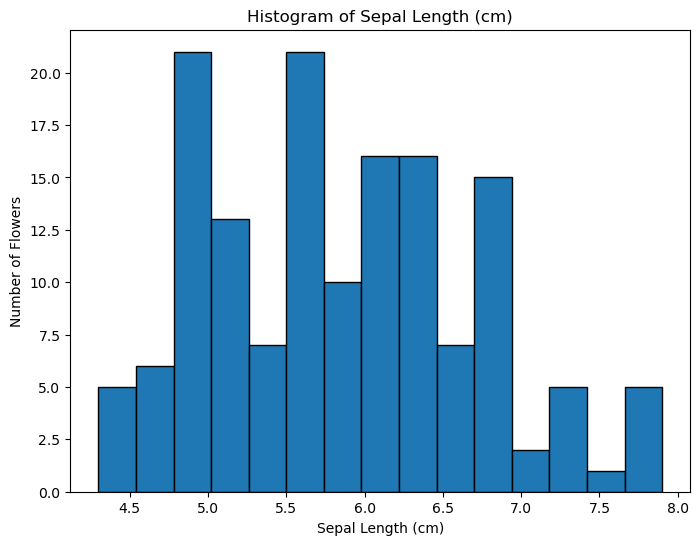

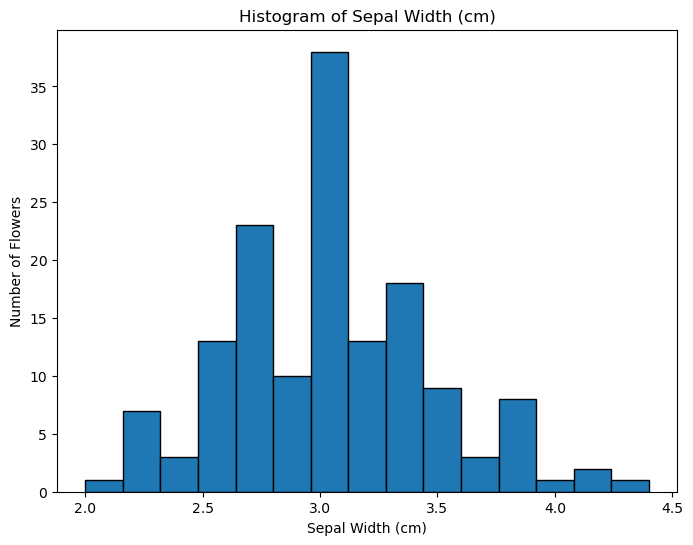

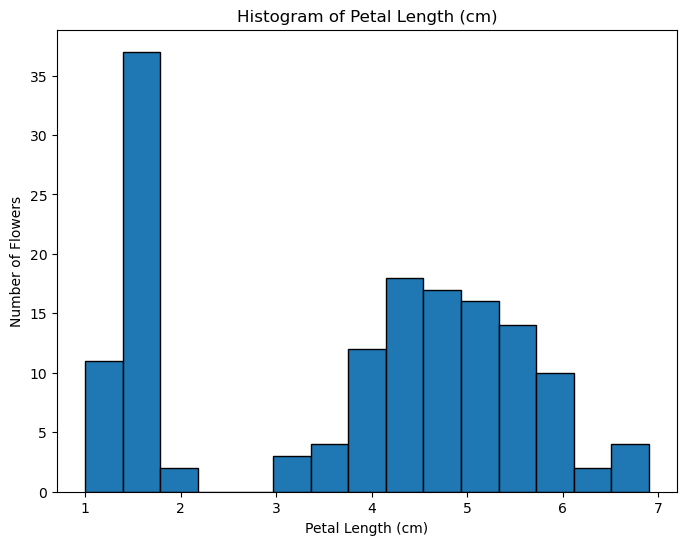

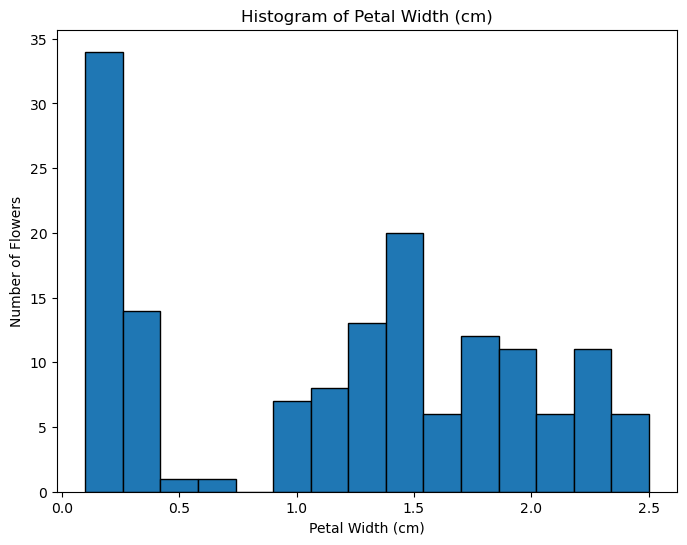

In [ ]:
# Create histograms for each measurement column.
for column in measurement_columns:
    
    # Create a clean file name by changing the column name to lowercase
    # and replacing spaces with underscores.
    # Replaces uppercase to lowercase,spaces with _ and (cm) with cm to match naming conventions for files.
    file_name = column.lower().replace(" ", "_").replace("(cm)", "cm")
    image_file = images_folder / f"{file_name}_histogram.png"

    # Create a new figure for the histogram.
    plot.figure(figsize=(8, 6))

    # Create the histogram.
    # bins=15 creates 15 bars in the histogram.
    plot.hist(iris_df[column], bins=15, edgecolor="black")

    # Add a title and axis labels.
    plot.title(f"Histogram of {column}")
    plot.xlabel(column)
    plot.ylabel("Number of Flowers")

    # Save the histogram as a PNG file.
    plot.savefig(image_file, bbox_inches="tight")

    # Display the histogram in the notebook.
    plot.show()

    # Close the figure so it does not interfere with the next chart.
    plot.close()

The histograms show how the values are spread out for each measurement.

The petal measurements seem to split into clearer groups than the sepal measurements. This makes it look like petal length and petal width are more useful when trying to tell the different Iris species apart.